# Lab03 Comp9517 z5565186 Han Qin、
The goal of this lab is to implement and compare the performance of a K-Nearest Neighbours
(KNN) classifier, a Decision Tree (DT) classifier, and a Stochastic Gradient Descent (SGD)
classifier on the Chinese MNIST dataset.
### Step 1: Import relevant packages

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
from sklearn.model_selection import train_test_split
# KNN classifier
from sklearn.neighbors import KNeighborsClassifier
# DT classifier
from sklearn.tree import DecisionTreeClassifier
# SGD classifier
from sklearn.linear_model import SGDClassifier
# comprision display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    )

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Step 2: Download the dataset

In [17]:
path = "Chinese_MNIST_Dataset"
mnist_csv = pd.read_csv(f'{path}/chinese_mnist.csv')
# 10 top 10 last will be print by default
# # can use minst.head(8)
# print(mnist_csv)
# # dtype for each coloum
print(mnist_csv.dtypes)
# # specific colum
# print(mnist_csv["code"])
# # filter the rows
# above_35 = mnist_csv[mnist_csv["code"] > 5]
# print(len(above_35))

# image path colums
mnist_csv["image_path"] = (
    path +
    "/data/data/input_"
    + mnist_csv["suite_id"].astype(str)
    + "_"
    + mnist_csv["sample_id"].astype(str)
    + "_"
    + mnist_csv["code"].astype(str)
    + ".jpg"
)


#  you can check how many images and labels there are in the entire dataset,
print(f"There are {len(mnist_csv)} images in the dataset")
#  what the size of each image is,
image_first = cv.imread(mnist_csv.loc[0, "image_path"])
print(f"the size of image is: {image_first.shape[:2]}")
#  how many classes there are
class_count = mnist_csv["value"].nunique()
print(f"There are {class_count} classes")
#  how many images are in each class.
print(mnist_csv["value"].value_counts().sort_index())

suite_id     int64
sample_id    int64
code         int64
value        int64
character      str
dtype: object
There are 15000 images in the dataset
the size of image is: (64, 64)
There are 15 classes
value
0            1000
1            1000
2            1000
3            1000
4            1000
5            1000
6            1000
7            1000
8            1000
9            1000
10           1000
100          1000
1000         1000
10000        1000
100000000    1000
Name: count, dtype: int64


> Also, have a look at some images of each label.

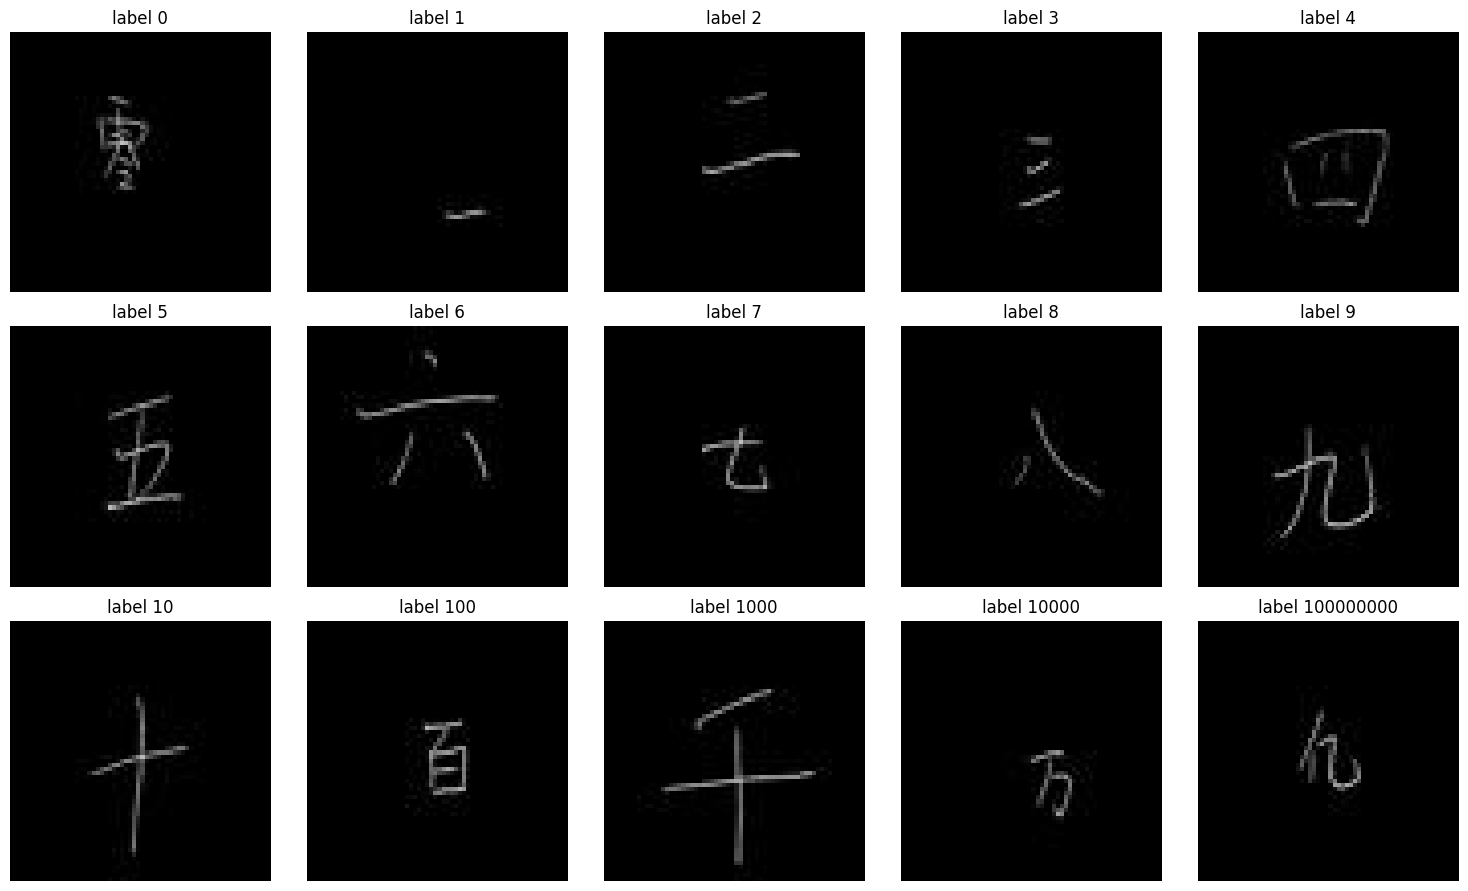

In [18]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.ravel()
sample = (mnist_csv.groupby('value', as_index=False)
          .sample(n=1, random_state=RANDOM_STATE)
          .sort_values('value')
)


# Show image of each class
for i in range(len(sample)):
    current_row = sample.iloc[i]

    image_path = current_row['image_path']
    class_label = int(current_row['value'])

    grayscale_image = cv.imread(image_path)

    axes[i].imshow(grayscale_image)
    axes[i].set_title(f'label {class_label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Split and sample the dataset

In [19]:
# extract 1000 test
train_pool, test = train_test_split(
    mnist_csv,
    test_size=1000,
    random_state=RANDOM_STATE,
    stratify=mnist_csv["value"]
)

print(f"test set: {len(test)}")
# 5000 trainning data
train_5000, _ = train_test_split(
    train_pool,
    train_size=5000,
    random_state=RANDOM_STATE,
    stratify=train_pool["value"]
)

print(f"extract {len(train_5000)}")
# 10000 training data
train_10000, _ = train_test_split(
    train_pool,
    train_size=10000,
    random_state=RANDOM_STATE,
    stratify=train_pool["value"]
)

print(f"extract {len(train_10000)}")

test set: 1000
extract 5000
extract 10000


### Step 4: Perform necessary data reshaping

In [20]:
# helper function to reshape
def load_images_and_labels(dataframe):
    images = []
    labels = []

    for _, row in dataframe.iterrows():
        image = cv.imread(row["image_path"], cv.IMREAD_GRAYSCALE)

        # Convert one 64 x 64 image into one 4096-dimensional feature vector.
        image_flattened = image.reshape(-1)
        images.append(image_flattened)
        labels.append(row["value"])

    X = np.array(images)
    y = np.array(labels)
    # X is the image, y is the label
    return X, y

X_train_5000, y_train_5000 = load_images_and_labels(train_5000)
X_train_10000, y_train_10000 = load_images_and_labels(train_10000)
X_test, y_test = load_images_and_labels(test)

print(X_train_5000.shape, y_train_5000.shape)
print(X_train_10000.shape, y_train_10000.shape)
print(X_test.shape, y_test.shape)

(5000, 4096) (5000,)
(10000, 4096) (10000,)
(1000, 4096) (1000,)


### Step 5: Initialise the classifier

In [21]:
model_5000 = {
    "knn": KNeighborsClassifier(n_neighbors=3),
    "dt": DecisionTreeClassifier(),
    "sgd": SGDClassifier(max_iter=250),
}

model_10000 = {
    "knn": KNeighborsClassifier(n_neighbors=3),
    "dt": DecisionTreeClassifier(),
    "sgd": SGDClassifier(max_iter=250),
}

### Step 6: Fit the classifier to the training data

In [22]:

for name, model in model_5000.items():
    model.fit(X_train_5000, y_train_5000)

for name, model in model_10000.items():
    model.fit(X_train_10000, y_train_10000)

/opt/miniconda3/envs/comp9517/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


### Step 7: Evaluate the trained model on the testing data

In [23]:
pred = {}
pred['5000'] = {}
pred['10000'] = {}
for name, model in model_5000.items():
    pred['5000'][name] = model.predict(X_test)


for name, model in model_10000.items():
    pred['10000'][name] = model.predict(X_test)

### Step 8: Report the performance of each classifier

######################  Result for 5000 training data #######################
######################  Result for knn model data #######################
              precision    recall  f1-score   support

           0     0.8889    0.6061    0.7207        66
           1     0.1519    0.9701    0.2626        67
           2     0.2054    0.3433    0.2570        67
           3     0.2985    0.2985    0.2985        67
           4     0.6087    0.2090    0.3111        67
           5     0.5455    0.0909    0.1558        66
           6     0.2830    0.2239    0.2500        67
           7     0.5714    0.2388    0.3368        67
           8     0.9500    0.8507    0.8976        67
           9     0.6000    0.1364    0.2222        66
          10     0.4416    0.5075    0.4722        67
         100     0.8571    0.1818    0.3000        66
        1000     0.6000    0.2687    0.3711        67
       10000     0.4444    0.1818    0.2581        66
   100000000     1.0000    0.1493    

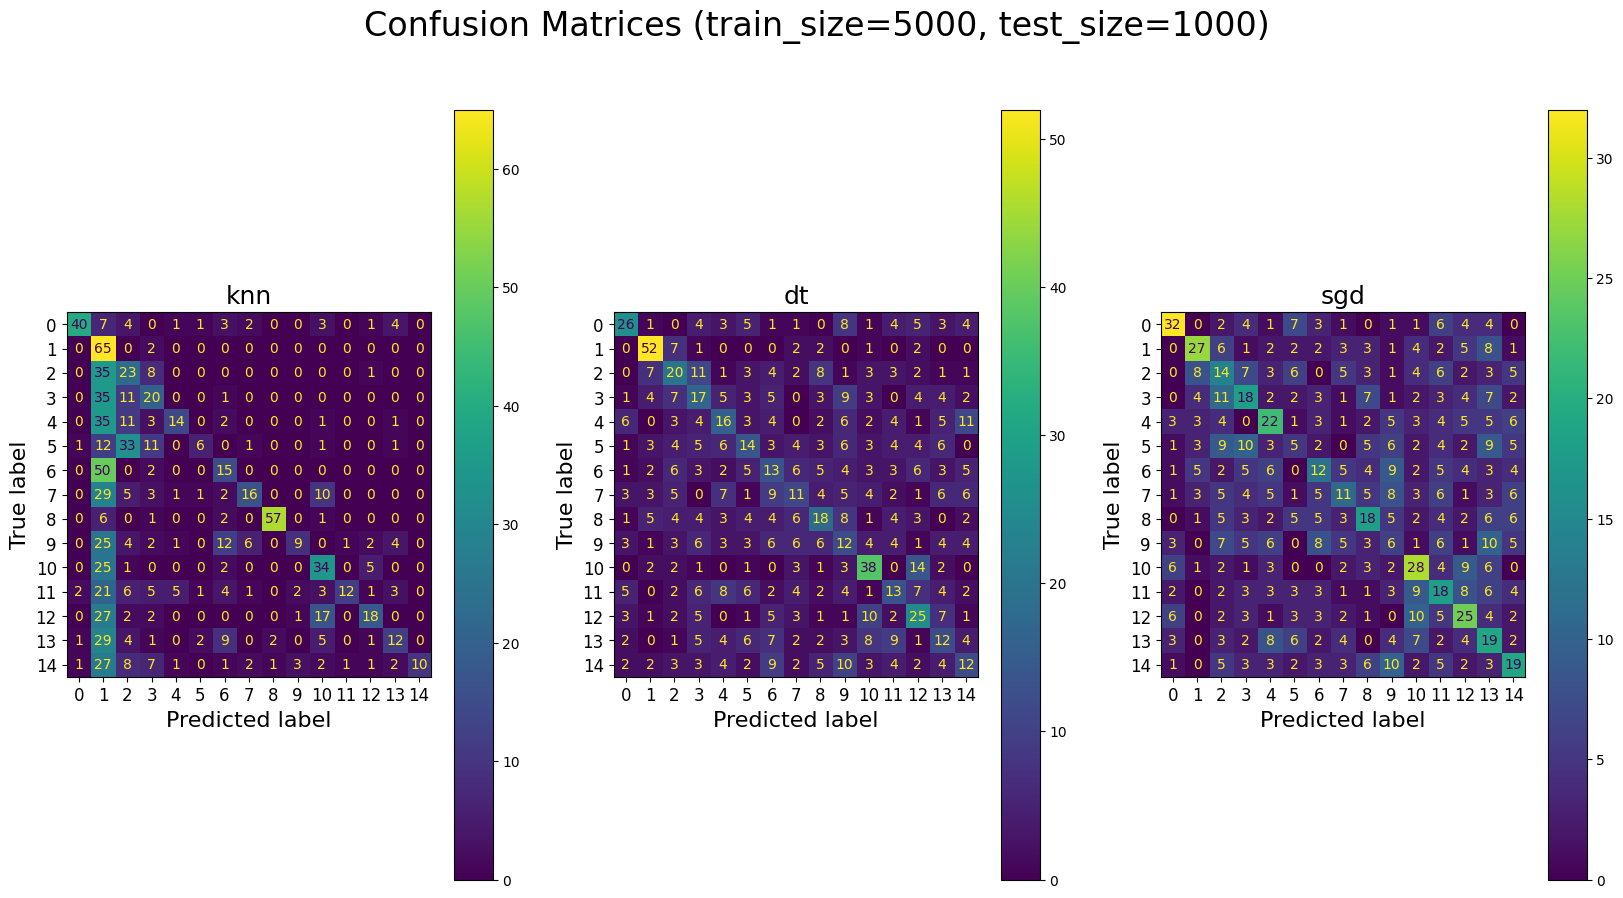

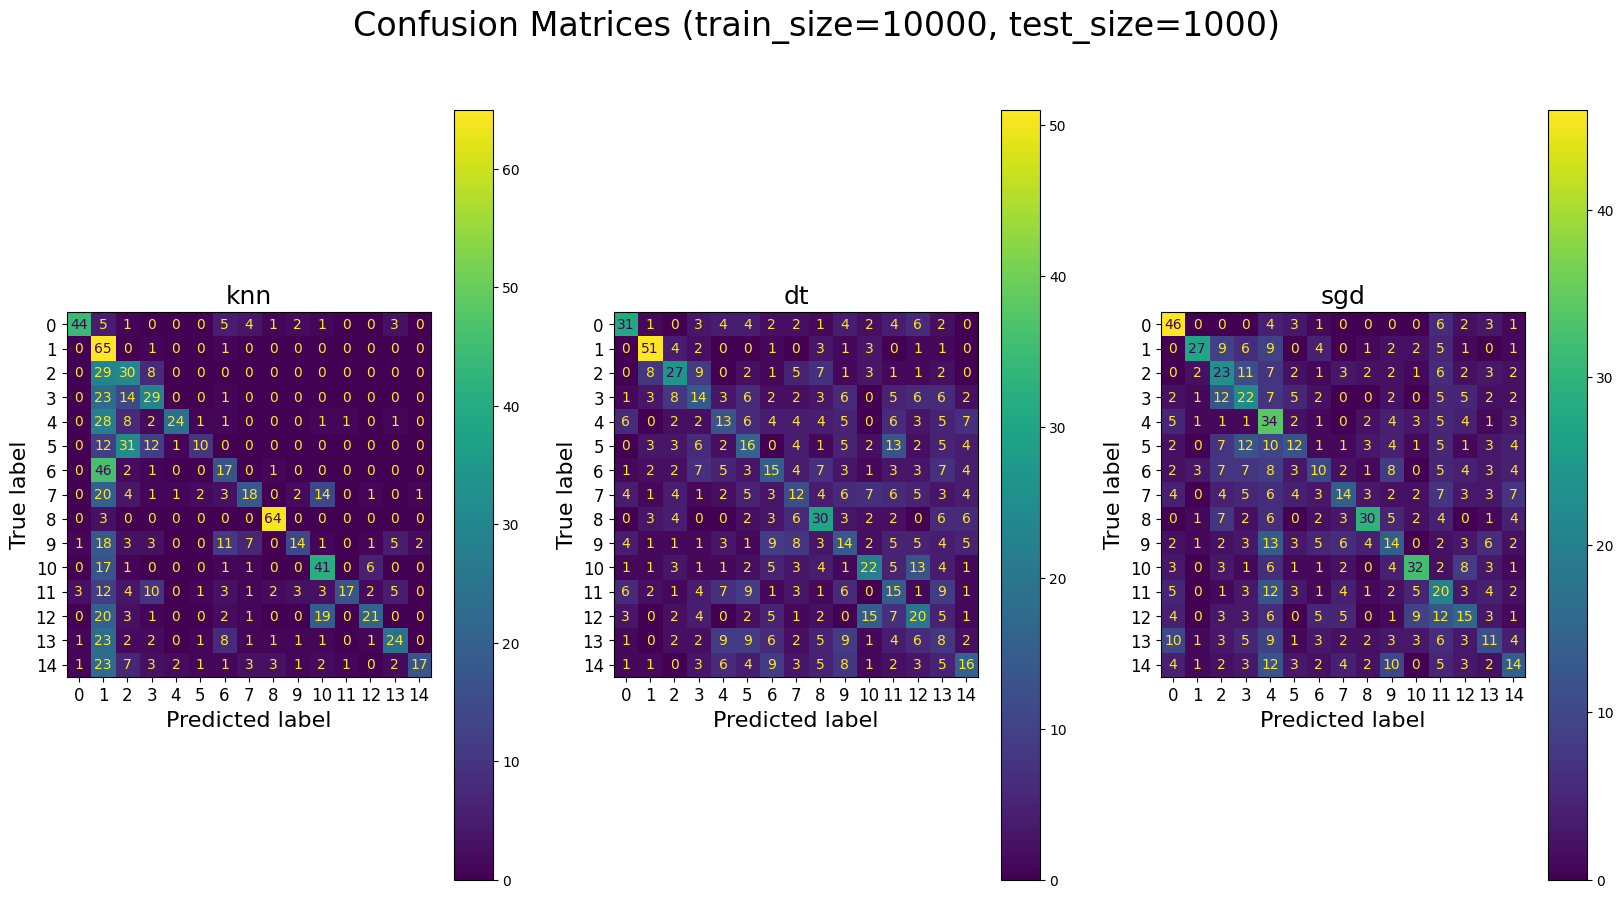

In [24]:

for num in "5000", "10000":
    i = 0
    fig, axes = plt.subplots(1, 3, figsize=(20, 10))
    axes = axes.ravel()
    fig.suptitle(f'Confusion Matrices (train_size={num}, test_size=1000)', fontsize=24)
    print(f'######################  Result for {num} training data #######################')
    for name, _ in model_5000.items():
        print(f'######################  Result for {name} model data #######################')
        cm = confusion_matrix(y_test, pred[num][name])
        print(classification_report(y_test, pred[num][name], digits=4, zero_division=0))

        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=axes[i], values_format='d')
        axes[i].set_title(name, fontsize=18)
        axes[i].set_xlabel('Predicted label', fontsize=16)
        axes[i].set_ylabel('True label', fontsize=16)
        axes[i].tick_params(axis='both', labelsize=12)
        i = i + 1